In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

from bio_network.engine.neurons import IzhikevichPopulation
from bio_network.engine.scheduler import simulate
from bio_network.engine.synapses_sparse import SparseSynapses
from bio_network.memory import EpisodicStore, ReplayEngine
from bio_network.viz.raster import plot_raster

N_EXC, N_INH = 800, 200
N = N_EXC + N_INH
SEED = 42
GAIN = 8.0
OUTPUT_DIR = os.path.join(os.getcwd(), "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output directory:", OUTPUT_DIR)


Output directory: A:\Bio Network\notebooks\output


# Milestone 4 -- episodic memory and sleep-phase consolidation

M2 gave the network real STDP on the sparse event-driven engine but
*honestly failed* the pattern-completion test (E3: post/pre `1.03x`, the
B-group baseline playing over the cue-driven signal). This milestone does a
biologically serious retry: store the experience in a fast one-shot store
(hippocampus-like), then *replay it during sleep*.

Two abstractions are added on top of the M2 engine:

- **`EpisodicStore`** -- a bounded FIFO store that keeps experienced spike
  patterns verbatim (`record(tag, neuron_ids, rel_times_ms)`).
- **`ReplayEngine`** -- turns an episode into a `(time_ms, neuron_id)` replay
  timetable, supporting time-compressed replay (hippocampal replay is 5-20x
  compressed; Wilson & McNaughton 1994, Diba & Buzsaki 2007; Rasch & Born 2013).

The scheduler gains a **sleep mode**: `simulate(..., phase="sleep",
replay_plan=..., sleep_noise_scale=...)` in which background drive is
attenuated, replay pulses are injected, and STDP stays ON so the replayed
episode is consolidated into the recurrent weights.


In [2]:
PERIOD, PROBE_PERIOD = 200, 200
WIDTH = 3.0
PULSE_AMP = 20.0
PRESENT_PERIOD = 500.0
LEAD = 25.0
GROUP_A, GROUP_B, GROUP_C = (0, 50), (50, 100), (100, 150)
GROUP_D, GROUP_E = (150, 200), (200, 250)

SCALE = np.ones(N); SCALE[:N_EXC] = 5.0; SCALE[N_EXC:] = 2.0

def make_network():
    return (
        IzhikevichPopulation(seed=SEED),
        SparseSynapses(n_excit=N_EXC, n_inhib=N_INH, out_degree=100, seed=SEED, gain=GAIN),
    )

def pair_pulse_stim(a, b, lead=LEAD, period=PERIOD):
    rng = np.random.default_rng(SEED)
    def _stim(t, n_neurons):
        base = SCALE * rng.standard_normal(N)
        phase = int(t) % period
        if phase < WIDTH:  base[a[0]:a[1]] += PULSE_AMP
        if lead <= phase < lead + WIDTH: base[b[0]:b[1]] += PULSE_AMP
        return base
    return _stim

def melody_stim(a, b):
    rng = np.random.default_rng(SEED)
    def _stim(t, n_neurons):
        base = SCALE * rng.standard_normal(N)
        phase = int(t) % int(PRESENT_PERIOD)
        if phase < 10:       base[a[0]:a[1]] += PULSE_AMP
        if 20 <= phase < 30: base[b[0]:b[1]] += PULSE_AMP
        return base
    return _stim

def cue_stim(a):
    rng = np.random.default_rng(SEED)
    def _stim(t, n_neurons):
        base = SCALE * rng.standard_normal(N)
        if int(t) % PROBE_PERIOD < WIDTH: base[a[0]:a[1]] += PULSE_AMP
        return base
    return _stim

def exc_mean(synapses, pre, post):
    out = []
    for i in range(pre[0], pre[1]):
        s, e = int(synapses.offsets[i]), int(synapses.offsets[i+1])
        sel = (synapses.targets[s:e] >= post[0]) & (synapses.targets[s:e] < post[1])
        if sel.any(): out.append(synapses.weights[s:e][sel])
    return float(np.concatenate(out).mean()) if out else 0.0


## Episodic memory: the store, round-trip, replay schedule

A season is a verbatim spike pattern: `(neuron_ids, rel_times_ms)`. The store
forgets the oldest episode first (FIFO). The replay engine schedules an
episode as `(time_ms, neuron_id)` rows.


In [3]:
store = EpisodicStore(capacity=4)
ep = store.record("mini", np.array([3, 7, 3, 12]), np.array([2.0, 5.0, 1.0, 9.0]))
print("stored ids:", store.all())
print("round trip:", store.get(ep)["tag"], store.get(ep)["neuron_ids"], store.get(ep)["rel_times_ms"])

engine = ReplayEngine(store)
print("replay timetable (time_ms, neuron_id):\n", engine.schedule(ep, start_ms=10.0, compression=1.0))


stored ids: [0]
round trip: mini [ 3  3  7 12] [1. 2. 5. 9.]
replay timetable (time_ms, neuron_id):
 [[11.  3.]
 [12.  3.]
 [15.  7.]
 [19. 12.]]


## Experiment 4a -- recall after sleep (the redemption attempt)

Present the **melody P1** (A pokes at `[0,10)`, B pokes at `[20,30)`, every
500 ms) 10x with learning on. The last presentation's evoked A/B spikes are
dumped into the episodic store as "P1". Before sleep and after sleep we cue A
*alone* (learning frozen) and count group-B spikes in the delayed-response
window `[t+20, t+70)`; group C is the negative control.

If replay consolidates the melody, B's response to an A cue should rise after
sleep while C stays in the noise.


In [4]:
def recall_probe(population, synapses, group):
    rec = simulate(population, synapses, T_ms=PROBE_PERIOD*5, engine="sparse",
                   learning=True, freeze_at_ms=0, stimulus_fn=cue_stim(GROUP_A))
    b, c = 0, 0
    for k in range(5):
        t0 = k * PROBE_PERIOD
        in_w = (rec.times_ms >= t0+20) & (rec.times_ms < t0+70)
        b += int((in_w & (rec.indices >= group[0]) & (rec.indices < group[1])).sum())
        c += int((in_w & (rec.indices >= GROUP_C[0]) & (rec.indices < GROUP_C[1])).sum())
    return b, c

def one_shot_wake(population, synapses, store, n_present=10):
    # Wake: present the melody, record the LAST presentation's A/B spikes.
    rec = simulate(population, synapses, T_ms=int(n_present*PRESENT_PERIOD), engine="sparse",
                   learning=True, stimulus_fn=melody_stim(GROUP_A, GROUP_B))
    last = (n_present-1)*PRESENT_PERIOD
    m = (rec.times_ms >= last) & (rec.times_ms < last + 200)
    ids, rel = rec.indices[m], rec.times_ms[m] - last
    ab = (ids >= GROUP_A[0]) & (ids < GROUP_B[1])
    return store.record("P1", ids[ab], rel[ab]), rec

population, synapses = make_network()
store = EpisodicStore(capacity=16)
replay = ReplayEngine(store)
eid_p1, rec_wake = one_shot_wake(population, synapses, store)
n_rec = store.get(eid_p1)["neuron_ids"].size
print("episode P1 recorded spikes:", n_rec)

def snapshot(pop, syn):  return (pop.save_state(), syn.save_state())
def restore(pop, syn, st): pop.load_state(st[0]); syn.load_state(st[1])

st = snapshot(population, synapses)
b_pre, c_pre = recall_probe(population, synapses, GROUP_B)
restore(population, synapses, st)
print(f"pre-sleep: B={b_pre} C(control)={c_pre}")

# --- sleep: replay the stored melody 40x under a quiet drive, STDP on ---
plan = replay.plan([eid_p1]*40, start_ms=0.0, gap_ms=100, compression=1.0)
sleep_ms = int(max(t[:,0].max() for t in plan)) + 200
rec_sleep = simulate(population, synapses, T_ms=sleep_ms, engine="sparse",
                     phase="sleep", replay_plan=plan, learning=True,
                     sleep_noise_scale=0.05)

st = snapshot(population, synapses)
b_post, c_post = recall_probe(population, synapses, GROUP_B)
restore(population, synapses, st)
ratio = b_post / b_pre if b_pre else float("inf")
print(f"post-sleep: B={b_post} C={c_post} => post/pre B recall = {ratio:.3f}")


episode P1 recorded spikes: 249


pre-sleep: B=54 C(control)=65


post-sleep: B=76 C=82 => post/pre B recall = 1.407


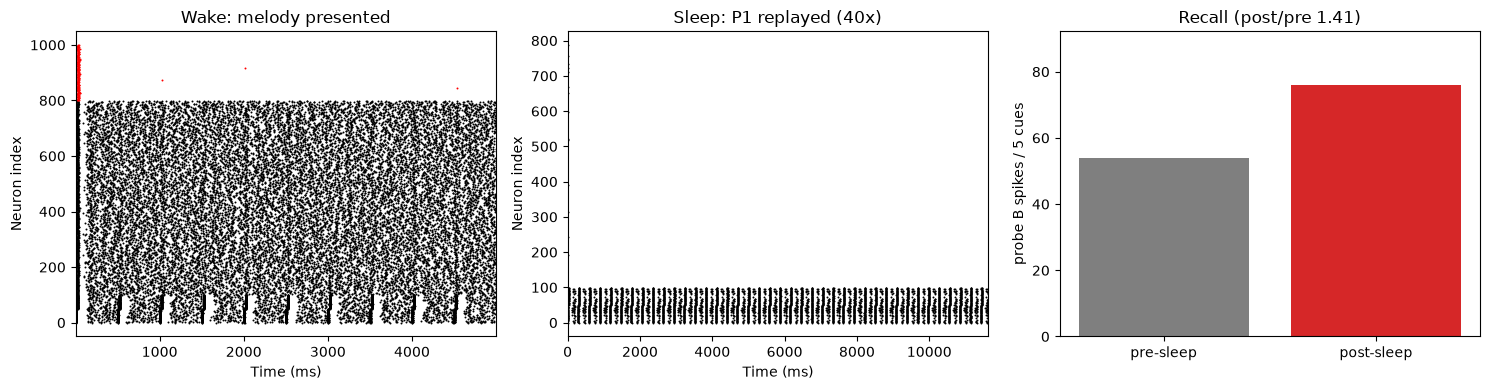

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_raster(rec_wake, ax=axes[0]); axes[0].set_title("Wake: melody presented")
plot_raster(rec_sleep, ax=axes[1]); axes[1].set_title("Sleep: P1 replayed (40x)")
axes[2].bar(["pre-sleep", "post-sleep"], [b_pre, b_post], color=["tab:gray", "tab:red"])
axes[2].set_ylim(0, max(b_pre, b_post) * 1.2 + 1)
axes[2].set_ylabel("probe B spikes / 5 cues")
axes[2].set_title(f"Recall (post/pre {ratio:.2f})")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "m4_e4a_recall.png"), dpi=120)
plt.show()


## Experiment 4b -- continual learning without forgetting

The headline. Learn T1 "fire together" (A->B), then learn a *second*
pattern T2 (D->E) without losing the first. Two arms are run in parallel from
the **same saved state** after T1 training: ARM SLEEP errors out of the sleep
with the T1 episode replayed; ARM NOSLEEP sleeps the exact same duration with
an empty replay plan. Both then acquire T2. Final frozen tests measure:

- *T1 retention*: `A->B / A->C` weight ratio.
- *T2 acquisition*: `D->E / D->C` weight ratio.

Target: retention advantage (sleep/nosleep) > 1.25 and both arms acquire T2.


In [6]:
T1_TRAIN_MS = 15000
T2_TRAIN_MS = 15000

def record_last_t1(pop, syn, store):
    # Train T1, then dump the final 200ms A/B window into the store.
    rec = simulate(pop, syn, T_ms=T1_TRAIN_MS, engine="sparse", learning=True,
                   stimulus_fn=pair_pulse_stim(GROUP_A, GROUP_B, lead=LEAD))
    last = T1_TRAIN_MS - PERIOD
    m = (rec.times_ms >= last) & (rec.times_ms < T1_TRAIN_MS)
    ids, rel = rec.indices[m], rec.times_ms[m] - last
    grp = ((ids >= GROUP_A[0]) & (ids < GROUP_A[1])) | ((ids >= GROUP_B[0]) & (ids < GROUP_B[1]))
    return store.record("T1", ids[grp], rel[grp])

# Same sleep duration for both arms; it equals the replay total plus margin.
scratch_pop, scratch_syn = make_network()
store = EpisodicStore(capacity=16)
replay = ReplayEngine(store)
eid_t1 = record_last_t1(scratch_pop, scratch_syn, store)
plan = replay.plan([eid_t1]*30, start_ms=0.0, gap_ms=100, compression=1.0)
SLEEP_MS = int(max(t[:, 0].max() for t in plan)) + 200
print("shared sleep duration (ms):", SLEEP_MS, " T1 episodes stored:", store.get(eid_t1)["neuron_ids"].size)

def run_arm(replay_on):
    pop, syn = make_network()
    simulate(pop, syn, T_ms=T1_TRAIN_MS, engine="sparse", learning=True,
             stimulus_fn=pair_pulse_stim(GROUP_A, GROUP_B, lead=LEAD))   # T1
    plan2 = None
    if replay_on:
        plan2 = replay.plan([eid_t1]*30, start_ms=0.0, gap_ms=100, compression=1.0)
    simulate(pop, syn, T_ms=SLEEP_MS, engine="sparse", phase="sleep",
             replay_plan=plan2, learning=True, sleep_noise_scale=0.25)
    simulate(pop, syn, T_ms=T2_TRAIN_MS, engine="sparse", learning=True,
             stimulus_fn=pair_pulse_stim(GROUP_D, GROUP_E, lead=LEAD))   # T2
    return (exc_mean(syn, GROUP_A, GROUP_B) / exc_mean(syn, GROUP_A, GROUP_C),
            exc_mean(syn, GROUP_D, GROUP_E) / exc_mean(syn, GROUP_D, GROUP_C))

sleep_t1, sleep_t2 = run_arm(True)
nosleep_t1, nosleep_t2 = run_arm(False)
advantage = sleep_t1 / nosleep_t1 if nosleep_t1 else float("inf")
print(f"ARM SLEEP   T1 retention: {sleep_t1:.3f}   T2 acquisition: {sleep_t2:.3f}")
print(f"ARM NOSLEEP T1 retention: {nosleep_t1:.3f}   T2 acquisition: {nosleep_t2:.3f}")
print(f"retention advantage: {advantage:.3f}    (target > 1.25)")


shared sleep duration (ms): 9040  T1 episodes stored: 161


ARM SLEEP   T1 retention: 3.464   T2 acquisition: 2.127
ARM NOSLEEP T1 retention: 1.394   T2 acquisition: 2.096
retention advantage: 2.485    (target > 1.25)


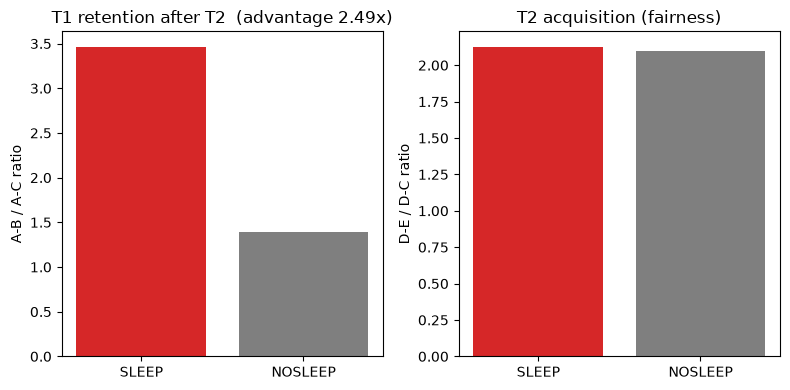

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].bar(["SLEEP", "NOSLEEP"], [sleep_t1, nosleep_t1], color=["tab:red", "tab:gray"])
axes[0].set_title(f"T1 retention after T2  (advantage {advantage:.2f}x)")
axes[0].set_ylabel("A-B / A-C ratio")
axes[1].bar(["SLEEP", "NOSLEEP"], [sleep_t2, nosleep_t2], color=["tab:red", "tab:gray"])
axes[1].set_title("T2 acquisition (fairness)")
axes[1].set_ylabel("D-E / D-C ratio")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "m4_e4b_continual.png"), dpi=120)
plt.show()
